## TF-IDF(Axis 1) + MLP(Axis 2)

In [1]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from pubmed_loader import PubMedQAData
from preprocessing import preprocess_tfidf
from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, training_curves, get_errors_by_type

In [2]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

In [3]:
def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

In [4]:
set_all_seeds()

All seeds set to 11


### 1. Data Loading & Preprocessing

In [5]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set, use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set, use_mesh=True)

print(f"train: {len(train_texts)} samples")
print(f"dev: {len(dev_texts)} samples")
print(f"test: {len(test_texts)} samples")

train: 450 samples
dev: 50 samples
test: 500 samples


In [6]:
print("Train:", np.bincount(train_labels))
print("Dev: ", np.bincount(dev_labels))
print("Test: ", np.bincount(test_labels))

Train: [249 152  49]
Dev:  [27 17  6]
Test:  [276 169  55]


In [7]:
combined_texts = train_texts + dev_texts
combined_labels = train_labels + dev_labels

### 2. TF-IDF Vectorisation

In [8]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

In [9]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=med_stopwords,
    max_features=1500,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_texts)
X_dev = vectorizer.transform(dev_texts)
X_test = vectorizer.transform(test_texts)

INPUT_DIM = X_train.shape[1]
print(f"TF-IDF input dim: {INPUT_DIM}")

TF-IDF input dim: 1500


#### 2.1 Dimensionality Reduction: LSA (TruncatedSVD)

In [10]:
from sklearn.decomposition import TruncatedSVD

In [11]:
# fit a full SVD to find the 90% variance threshold
svd_analysis = TruncatedSVD(n_components=500, random_state=RANDOM_SEED)
svd_analysis.fit(X_train)

BEST_N = int(np.searchsorted(np.cumsum(svd_analysis.explained_variance_ratio_), 0.80) + 1)
print(f"Components needed to explain 80% variance: {BEST_N}")

Components needed to explain 80% variance: 237


In [12]:
lsa = TruncatedSVD(n_components=BEST_N, random_state=RANDOM_SEED)

X_train_lsa = lsa.fit_transform(X_train)
X_dev_lsa = lsa.transform(X_dev)
X_test_lsa = lsa.transform(X_test)
print(f"Shape: {X_train_lsa.shape}")
INPUT_DIM_LSA = X_train_lsa.shape[1]

Shape: (450, 237)


### 3. MLP

Wrap datases in DataLoader objects

In [13]:
def convert_to_tensor(X, labels):
    # Convert sparse matrix & label list to TensorDataset.
    # both sparse matrix and numpy array
    if hasattr(X, 'toarray'):
        X = X.toarray()
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(X, y)

In [14]:
BATCH_SIZE = 64

train_dataset = convert_to_tensor(X_train, train_labels)
dev_dataset = convert_to_tensor(X_dev, dev_labels)
test_dataset = convert_to_tensor(X_test,test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [15]:
train_dataset_lsa = convert_to_tensor(X_train_lsa, train_labels)
dev_dataset_lsa = convert_to_tensor(X_dev_lsa, dev_labels)
test_dataset_lsa = convert_to_tensor(X_test_lsa, test_labels)

train_loader_lsa = DataLoader(train_dataset_lsa, batch_size=BATCH_SIZE, shuffle=True)
dev_loader_lsa = DataLoader(dev_dataset_lsa, batch_size=BATCH_SIZE)
test_loader_lsa = DataLoader(test_dataset_lsa, batch_size=BATCH_SIZE)

MLP Architecture

In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )
    
    def forward(self, x):
        return self.network(x)

Training

In [17]:
# Training Loop
def train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate, class_weights=None):
    # If weights is not None, apply them to the loss function
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(next(model.parameters()).device))
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses = []
    all_dev_losses = []

    # Track the best model
    best_dev_loss = float('inf')
    best_state = None

    for e in range(num_epochs):
        total_correct = 0
        total_trained = 0
        train_losses = []

        model.train()

        for batch_X, batch_y in train_loader:
            # Reset the optimizer
            optimizer.zero_grad()

            # Use the model to perform forward inference on the input data.
            # This will run the forward() function.
            output = model(batch_X)

            # Compute the loss for the current batch of data
            batch_loss = loss_fn(output, batch_y)

            # Perform back propagation to compute the gradients with respect to each weight
            batch_loss.backward()

            # Update the weights using the compute gradients
            optimizer.step()

            # Record the loss from this sample to keep track of progress.
            train_losses.append(batch_loss.item())

            # Count correct labels so we can compute accuracy on the training set
            predicted_labels = output.argmax(1)
            total_correct += (predicted_labels == batch_y).sum().item()
            total_trained += batch_y.size(0)

        train_accuracy = total_correct/total_trained*100
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_accuracy))
        
        all_train_losses.append(np.mean(train_losses))

        # Switch model to evaluation mode
        model.eval()
        total_correct = 0
        total_trained = 0
        dev_losses = []

        with torch.no_grad():
            for dev_input_ids, dev_labels in dev_loader:
                dev_output = model(dev_input_ids)
                
                dev_loss = loss_fn(dev_output, dev_labels)

                dev_losses.append(dev_loss.item())
                
                predicted_labels = dev_output.argmax(1)
                total_correct += (predicted_labels == dev_labels).sum().item()
                total_trained += dev_labels.size(0)
        
        dev_accuracy = total_correct/total_trained*100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(np.mean(dev_losses))
        
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Validation Loss: {:.4f}".format(np.mean(dev_losses)),
              "Validation Accuracy: {:.4f}%".format(dev_accuracy))

        # Save the best model & Early Stopping
        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    # Restore the optimal weight and then return
    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    
    return model, all_train_losses, all_dev_losses

In [18]:
set_all_seeds()

num_epochs = 15
learning_rate = 0.001

model = MLP(input_dim=INPUT_DIM)
trained_model, train_losses, dev_losses = train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate)


All seeds set to 11
Epoch: 1/15 Training Loss: 1.0868 Training Accuracy: 37.7778%
Epoch: 1/15 Validation Loss: 1.0670 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0670)
Epoch: 2/15 Training Loss: 1.0458 Training Accuracy: 56.4444%
Epoch: 2/15 Validation Loss: 1.0394 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0394)
Epoch: 3/15 Training Loss: 0.9990 Training Accuracy: 55.3333%
Epoch: 3/15 Validation Loss: 1.0068 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0068)
Epoch: 4/15 Training Loss: 0.9866 Training Accuracy: 55.3333%
Epoch: 4/15 Validation Loss: 0.9732 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9732)
Epoch: 5/15 Training Loss: 0.9947 Training Accuracy: 55.3333%
Epoch: 5/15 Validation Loss: 0.9595 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9595)
Epoch: 6/15 Training Loss: 0.8703 Training Accuracy: 55.3333%
Epoch: 6/15 Validation Loss: 0.9549 Validation Accuracy: 54.0000%
Be

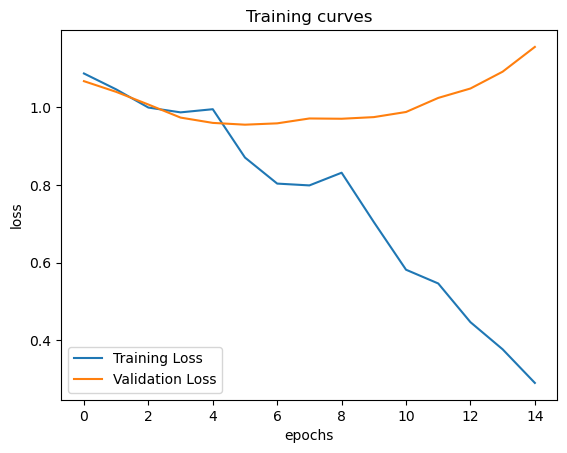

In [19]:
training_curves(train_losses, dev_losses)

### 4. Evaluation

Predict

In [20]:
def predict(model, test_loader):
    model.eval()
    gold_labs = []  # gold labels to return
    pred_labs = []  # predicted labels to return

    with torch.no_grad():
        for inputs, labels in test_loader:
            output = model(inputs)
            predicted_labels = output.argmax(1)
            
            gold_labs.extend(labels.tolist())
            pred_labs.extend(predicted_labels.tolist())

    return gold_labs, pred_labs

In [21]:
y_true, y_pred = predict(trained_model, test_loader)

evaluate(y_pred, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


==== Error Analysis ====

True=yes (total=276, correct=276, error=0):

True=no (total=169, correct=0, error=169):
   Predicted yes: 169/169 (100.0%)

True=maybe (total=55, correct=0, error=55):
   Predicted yes: 55/55 (100.0%)


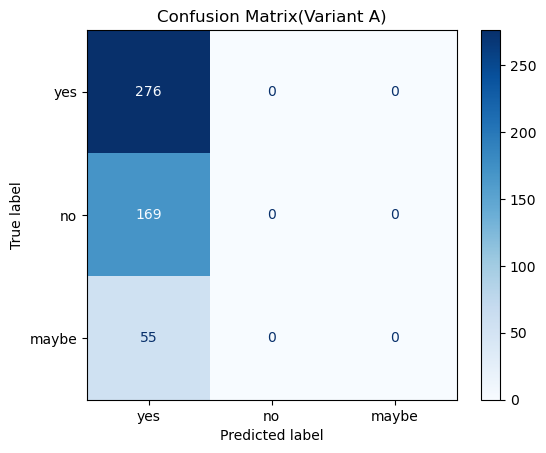

In [22]:
plot_confusion_matrix(y_true, y_pred, title="Variant A")

### 5. With Class Weighting

In [24]:
counts = np.bincount(train_labels)
counts_tensor = torch.FloatTensor(counts)
weights = 1.0 / counts_tensor
weights = weights / weights.sum() * 3 # normalization

print(f"counts: {counts} \nWeights: {weights}")

counts: [249 152  49] 
Weights: tensor([0.3886, 0.6366, 1.9748])


In [25]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM)
trained_model_balanced, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model, 
                                                    train_loader,
                                                    dev_loader, 
                                                    learning_rate,
                                                    weights)


All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.1008 Training Accuracy: 33.7778%
Epoch: 1/15 Validation Loss: 1.0995 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0995)
Epoch: 2/15 Training Loss: 1.0896 Training Accuracy: 44.4444%
Epoch: 2/15 Validation Loss: 1.0986 Validation Accuracy: 32.0000%
Best model saved (validation_loss=1.0986)
Epoch: 3/15 Training Loss: 1.0839 Training Accuracy: 50.6667%
Epoch: 3/15 Validation Loss: 1.0976 Validation Accuracy: 36.0000%
Best model saved (validation_loss=1.0976)
Epoch: 4/15 Training Loss: 1.0689 Training Accuracy: 71.7778%
Epoch: 4/15 Validation Loss: 1.0964 Validation Accuracy: 52.0000%
Best model saved (validation_loss=1.0964)
Epoch: 5/15 Training Loss: 1.0496 Training Accuracy: 80.2222%
Epoch: 5/15 Validation Loss: 1.0927 Validation Accuracy: 52.0000%
Best model saved (validation_loss=1.0927)
Epoch: 6/15 Training Loss: 1.0020 Training Accuracy: 90.8889%
Epoch:

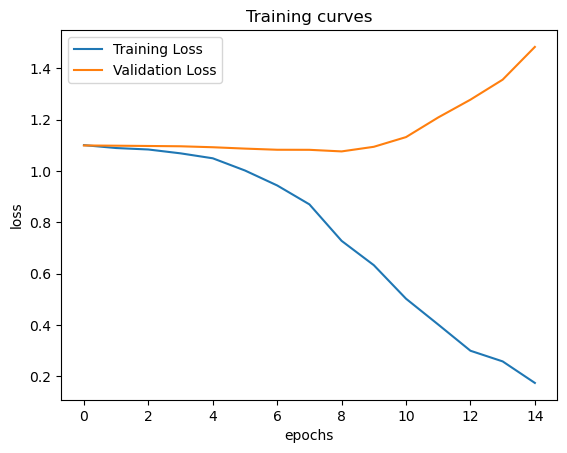

In [26]:
training_curves(train_losses, dev_losses)

In [27]:
y_true, y_pred_balanced = predict(trained_model_balanced, test_loader)

evaluate(y_pred_balanced, y_true, "Test_set")


── Test_set ──
Accuracy: 0.4560  Macro-F1: 0.3657
              precision    recall  f1-score   support

         yes       0.57      0.58      0.58       276
          no       0.38      0.34      0.36       169
       maybe       0.15      0.18      0.16        55

    accuracy                           0.46       500
   macro avg       0.37      0.37      0.37       500
weighted avg       0.46      0.46      0.46       500



==== Error Analysis ====

True=yes (total=276, correct=161, error=115):
   Predicted no: 83/276 (30.1%)
   Predicted maybe: 32/276 (11.6%)

True=no (total=169, correct=57, error=112):
   Predicted yes: 86/169 (50.9%)
   Predicted maybe: 26/169 (15.4%)

True=maybe (total=55, correct=10, error=45):
   Predicted yes: 36/55 (65.5%)
   Predicted no: 9/55 (16.4%)


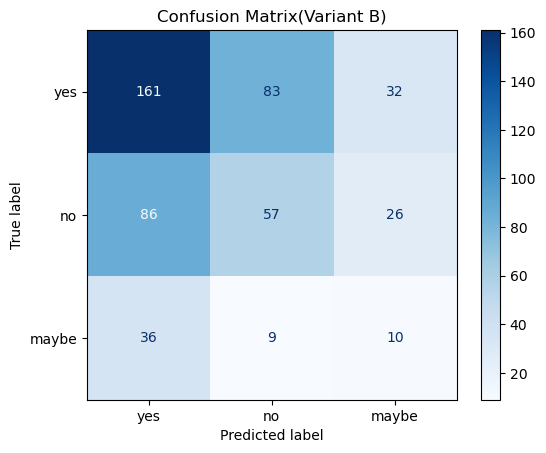

In [28]:
plot_confusion_matrix(y_true, y_pred_balanced, title="Variant B")

In [29]:
get_errors_by_type(data, y_true, y_pred_balanced, true_class="maybe", pred_class="yes", n=3)

True=maybe  Predicted=yes  (total 36 errors, showing 3)
  Question: Expression of c-kit protooncogen in hepatitis B virus-induced chronic hepatitis, cirrhosis and hepatocellular carcinoma: has it a diagnostic role?
  Context: ['Paraffin-embedded tissues in Cukurova University Faculty of Medicine Department of Pathology between January 2002 and February 2006 were searched restrospectively to investigate this issue. We performed immunohistochemistry on biopsies of 125 patients with HBV infection, grouped as: mild, moderate and severe hepatitis, cirrhosis and HCC, 25 patients in each of them, using anti c-kit monoclonal antibody. The severity of parenchymal inflammation and of interface hepatitis was semiquantitatively graded on a haematoxylin and eosin stained paraffin sections. Additionally, 50 more HCC, formed on HBV basis, were studied to determine the prevalence of c-kit overexpression.', 'In cirrhotic liver, lower intensity of staining and rarely c-kit positivity were present. The g

In [30]:
get_errors_by_type(data, y_true, y_pred_balanced, true_class="no", pred_class="yes", n=3)

True=no  Predicted=yes  (total 86 errors, showing 3)
  Question: Does strategy training reduce age-related deficits in working memory?
  Context: ['Older adults typically perform worse on measures of working memory (WM) than do young adults; however, age-related differences in WM performance might be reduced if older adults use effective encoding strategies.', 'The purpose of the current experiment was to evaluate WM performance after training individuals to use effective encoding strategies.', 'Participants in the training group (older adults: n = 39; young adults: n = 41) were taught about various verbal encoding strategies and their differential effectiveness and were trained to use interactive imagery and sentence generation on a list-learning task. Participants in the control group (older: n = 37; young: n = 38) completed an equally engaging filler task. All participants completed a pre- and post-training reading span task, which included self-reported strategy use, as well as two

### 6. With Dimensionality Reduction

In [31]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM_LSA)
trained_model_balanced_lsa, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model,
                                                    train_loader_lsa,
                                                    dev_loader_lsa, 
                                                    learning_rate,
                                                    weights)

All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.0949 Training Accuracy: 33.7778%
Epoch: 1/15 Validation Loss: 1.1040 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1040)
Epoch: 2/15 Training Loss: 1.0905 Training Accuracy: 33.7778%
Epoch: 2/15 Validation Loss: 1.1039 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1039)
Epoch: 3/15 Training Loss: 1.0889 Training Accuracy: 34.0000%
Epoch: 3/15 Validation Loss: 1.1043 Validation Accuracy: 34.0000%
Epoch: 4/15 Training Loss: 1.1009 Training Accuracy: 33.7778%
Epoch: 4/15 Validation Loss: 1.1044 Validation Accuracy: 34.0000%
Epoch: 5/15 Training Loss: 1.0922 Training Accuracy: 34.8889%
Epoch: 5/15 Validation Loss: 1.1033 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1033)
Epoch: 6/15 Training Loss: 1.0811 Training Accuracy: 44.0000%
Epoch: 6/15 Validation Loss: 1.1029 Validation Accuracy: 36.0000%
Best model saved (valida

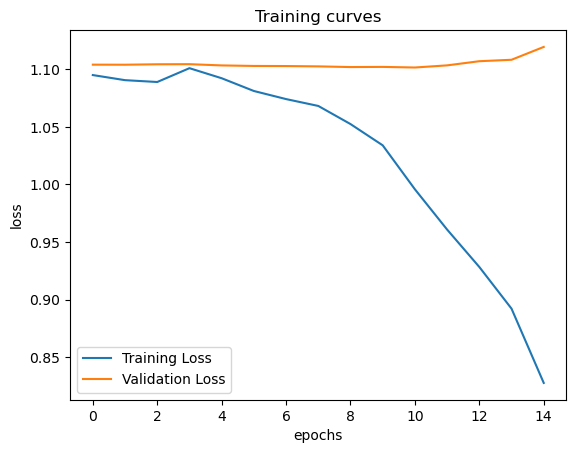

In [32]:
training_curves(train_losses, dev_losses)

In [33]:
y_true, y_pred_balanced_lsa = predict(trained_model_balanced_lsa, test_loader_lsa)

evaluate(y_pred_balanced_lsa, y_true, "Test_set")


── Test_set ──
Accuracy: 0.3960  Macro-F1: 0.2798
              precision    recall  f1-score   support

         yes       0.59      0.22      0.32       276
          no       0.34      0.80      0.48       169
       maybe       0.50      0.02      0.04        55

    accuracy                           0.40       500
   macro avg       0.48      0.35      0.28       500
weighted avg       0.50      0.40      0.34       500



==== Error Analysis ====

True=yes (total=276, correct=61, error=215):
   Predicted no: 214/276 (77.5%)
   Predicted maybe: 1/276 (0.4%)

True=no (total=169, correct=136, error=33):
   Predicted yes: 33/169 (19.5%)

True=maybe (total=55, correct=1, error=54):
   Predicted yes: 9/55 (16.4%)
   Predicted no: 45/55 (81.8%)


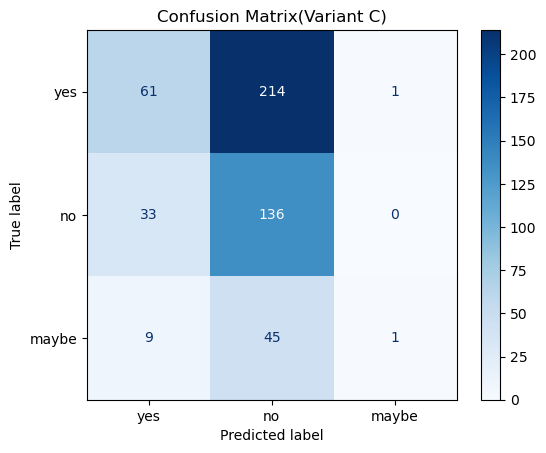

In [34]:
plot_confusion_matrix(y_true, y_pred_balanced_lsa, title="Variant C")

In [35]:
get_errors_by_type(data, y_true, y_pred_balanced_lsa, true_class="yes", pred_class="no", n=3)
#get_errors_by_type(data, y_true, y_pred_balanced_lsa, true_class="maybe", pred_class="yes", n=3)

True=yes  Predicted=no  (total 214 errors, showing 3)
  Question: Is anorectal endosonography valuable in dyschesia?
  Context: ['Dyschesia can be provoked by inappropriate defecation movements. The aim of this prospective study was to demonstrate dysfunction of the anal sphincter and/or the musculus (m.) puborectalis in patients with dyschesia using anorectal endosonography.', 'Twenty consecutive patients with a medical history of dyschesia and a control group of 20 healthy subjects underwent linear anorectal endosonography (Toshiba models IUV 5060 and PVL-625 RT). In both groups, the dimensions of the anal sphincter and the m. puborectalis were measured at rest, and during voluntary squeezing and straining. Statistical analysis was performed within and between the two groups.', 'The anal sphincter became paradoxically shorter and/or thicker during straining (versus the resting state) in 85% of patients but in only 35% of control subjects. Changes in sphincter length were statisticall

### 7. With Dimensionality Reduction (no class Weighting)

In [36]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM_LSA)
trained_model_lsa, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model,
                                                    train_loader_lsa,
                                                    dev_loader_lsa, 
                                                    learning_rate)

All seeds set to 11
Epoch: 1/15 Training Loss: 1.0714 Training Accuracy: 33.7778%
Epoch: 1/15 Validation Loss: 1.0672 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0672)
Epoch: 2/15 Training Loss: 1.0454 Training Accuracy: 37.1111%
Epoch: 2/15 Validation Loss: 1.0458 Validation Accuracy: 40.0000%
Best model saved (validation_loss=1.0458)
Epoch: 3/15 Training Loss: 1.0223 Training Accuracy: 53.3333%
Epoch: 3/15 Validation Loss: 1.0211 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0211)
Epoch: 4/15 Training Loss: 1.0151 Training Accuracy: 54.6667%
Epoch: 4/15 Validation Loss: 0.9935 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9935)
Epoch: 5/15 Training Loss: 0.9387 Training Accuracy: 55.3333%
Epoch: 5/15 Validation Loss: 0.9711 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9711)
Epoch: 6/15 Training Loss: 0.9242 Training Accuracy: 55.3333%
Epoch: 6/15 Validation Loss: 0.9566 Validation Accuracy: 54.0000%
Be

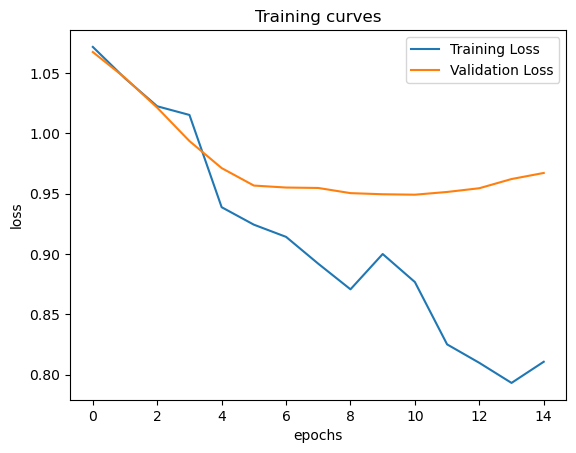

In [37]:
training_curves(train_losses, dev_losses)

In [38]:
y_true, y_pred_lsa = predict(trained_model_lsa, test_loader_lsa)

evaluate(y_pred_lsa, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


==== Error Analysis ====

True=yes (total=276, correct=276, error=0):

True=no (total=169, correct=0, error=169):
   Predicted yes: 169/169 (100.0%)

True=maybe (total=55, correct=0, error=55):
   Predicted yes: 55/55 (100.0%)


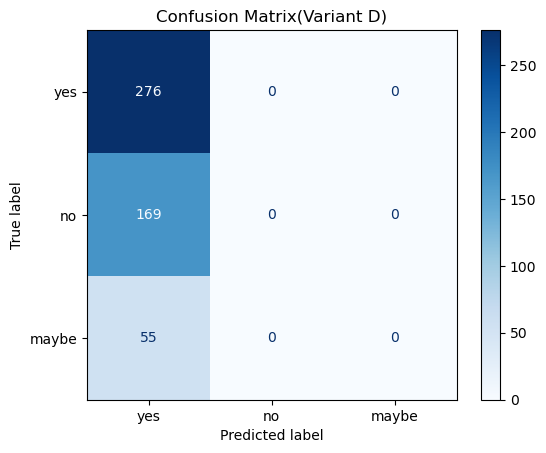

In [39]:
plot_confusion_matrix(y_true, y_pred_lsa, title="Variant D")

In [40]:
get_errors_by_type(data, y_true, y_pred_lsa, true_class="no", pred_class="yes", n=3)

True=no  Predicted=yes  (total 169 errors, showing 3)
  Question: Does strategy training reduce age-related deficits in working memory?
  Context: ['Older adults typically perform worse on measures of working memory (WM) than do young adults; however, age-related differences in WM performance might be reduced if older adults use effective encoding strategies.', 'The purpose of the current experiment was to evaluate WM performance after training individuals to use effective encoding strategies.', 'Participants in the training group (older adults: n = 39; young adults: n = 41) were taught about various verbal encoding strategies and their differential effectiveness and were trained to use interactive imagery and sentence generation on a list-learning task. Participants in the control group (older: n = 37; young: n = 38) completed an equally engaging filler task. All participants completed a pre- and post-training reading span task, which included self-reported strategy use, as well as tw